In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import optuna

from sklearn.model_selection import train_test_split, KFold
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

optuna.logging.set_verbosity(optuna.logging.WARNING)

In [2]:
df = pd.read_csv("data/ZTF_DESI_matched_lc_cuts_z_cuts_hostprop_cleaned.csv")

In [3]:

feature_cols = [
    "DESI_FASTSPEC_LOGMSTAR",
    "DESI_FASTSPEC_SFR",
    "DESI_FASTSPEC_VDISP",
    "DESI_FASTSPEC_DN4000",
    "DESI_FASTSPEC_g_minus_r",
    "DESI_FASTSPEC_AGE",
]

target_col = "residuals"
yerr_all = df["ZTF_sigma_mu"]

X = df[feature_cols]
y = df[target_col]


In [4]:
Xtr, Xte, ytr, yte, yerr_tr, yerr_te = train_test_split(
    X, y, yerr_all, test_size=0.2, random_state=42
)

In [5]:
def objective(trial):
    # Architecture search
    n_layers = trial.suggest_int("n_layers", 1, 3)
    layers = tuple(
        trial.suggest_int(f"units_{i}", 16, 128, log=True)
        for i in range(n_layers)
    )

    # Regularization and optimizer
    alpha = trial.suggest_float("alpha", 1e-5, 10.0, log=True)
    lr = trial.suggest_float("learning_rate_init", 1e-4, 0.1, log=True)
    solver = trial.suggest_categorical("solver", ["adam", "lbfgs"])
    activation = trial.suggest_categorical("activation", ["relu", "tanh"])

    # 5-fold CV with inverse-variance weighting
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    cv_scores = []

    for train_idx, val_idx in kf.split(Xtr):
        X_fold_tr, X_fold_val = Xtr.iloc[train_idx], Xtr.iloc[val_idx]
        y_fold_tr, y_fold_val = ytr.iloc[train_idx], ytr.iloc[val_idx]
        yerr_fold_tr = yerr_tr.iloc[train_idx]
        yerr_fold_val = yerr_tr.iloc[val_idx]

        w_fold = 1.0 / (yerr_fold_tr.to_numpy() ** 2)

        pipe = Pipeline([
            ("scaler", StandardScaler()),
            ("mlp", MLPRegressor(
                hidden_layer_sizes=layers,
                alpha=alpha,
                learning_rate_init=lr,
                solver=solver,
                activation=activation,
                max_iter=2000,
                random_state=42,
                early_stopping=True,
                validation_fraction=0.15,
                n_iter_no_change=20,
            )),
        ])

        try:
            pipe.fit(X_fold_tr, y_fold_tr, mlp__sample_weight=w_fold)
            y_pred_val = pipe.predict(X_fold_val)
            score = weighted_rmse(y_fold_val.to_numpy(), y_pred_val, yerr_fold_val.to_numpy())
            cv_scores.append(score)
        except Exception:
            return float("inf")

    return np.mean(cv_scores)

In [6]:
study = optuna.create_study(
    direction="minimize",
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Best trial: {study.best_trial.number}")
print(f"Best weighted CV RMSE: {study.best_value:.5f}")
print(f"Best hyperparameters:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

  0%|          | 0/50 [00:00<?, ?it/s]

Best trial: 0
Best weighted CV RMSE: inf
Best hyperparameters:
  n_layers: 2
  units_0: 116
  units_1: 73
  alpha: 0.039079671568228794
  learning_rate_init: 0.00029380279387035364
  solver: adam
  activation: relu


In [7]:
bp = study.best_params
layers_best = tuple(bp[f"units_{i}"] for i in range(bp["n_layers"]))

best_mlp = Pipeline([
    ("scaler", StandardScaler()),
    ("mlp", MLPRegressor(
        hidden_layer_sizes=layers_best,
        alpha=bp["alpha"],
        learning_rate_init=bp["learning_rate_init"],
        solver=bp["solver"],
        activation=bp["activation"],
        max_iter=2000,
        random_state=42,
        early_stopping=False,
    )),
])

best_mlp.fit(Xtr, ytr)
yhat = best_mlp.predict(Xte)

In [10]:
test_rmse = np.sqrt(mean_squared_error(yte, yhat))
test_mae = mean_absolute_error(yte, yhat)
test_r2 = r2_score(yte, yhat)

print(f"Test RMSE:          {test_rmse:.5f}")
print(f"Test MAE:           {test_mae:.5f}")
print(f"Test R²:            {test_r2:.5f}")

Test RMSE:          0.20011
Test MAE:           0.14461
Test R²:            -0.00937


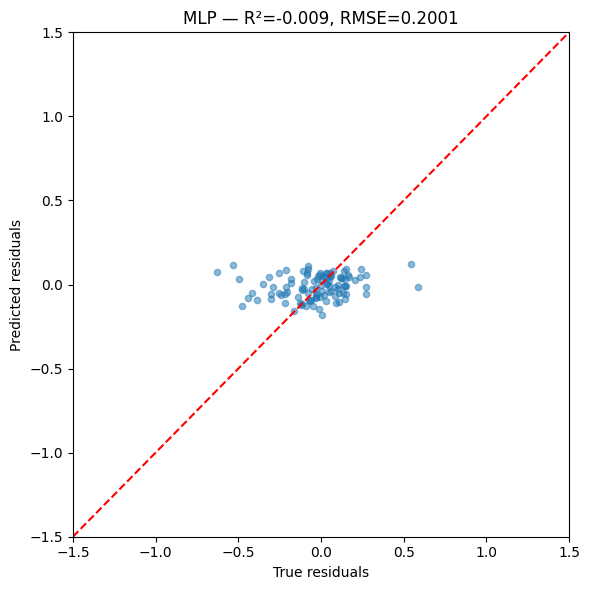

In [11]:
plt.figure(figsize=(6, 6))
plt.scatter(yte, yhat, alpha=0.5, s=20)
plt.xlabel("True residuals")
plt.ylabel("Predicted residuals")
plt.axline((0, 0), slope=1, linestyle="--", color="red")
plt.xlim(-1.5, 1.5)
plt.ylim(-1.5, 1.5)
plt.title(f"MLP — R²={test_r2:.3f}, RMSE={test_rmse:.4f}")
plt.tight_layout()
plt.show()

In [12]:
print(f"\nBest MLP architecture: {layers_best}")
print(f"Activation: {bp['activation']}")
print(f"Solver: {bp['solver']}")
print(f"L2 alpha: {bp['alpha']:.6f}")
print(f"Learning rate: {bp['learning_rate_init']:.6f}")


Best MLP architecture: (116, 73)
Activation: relu
Solver: adam
L2 alpha: 0.039080
Learning rate: 0.000294
